### Building Basic Chatbot using Langgraph(GraphAPI)


In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Message have the type 'list'. The 'add_messages' function
    # in the annotation defines how this state key should be updated
    # in the case, it appends messages to the list, rather than overwriting them.
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [3]:
graph_builder

In [4]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model = 'openai/gpt-oss-120b')

In [6]:
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000019A02CD1E80>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000019A02CD2BA0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
def chatbot(state: State):
    return {'messages':[llm.invoke(state['messages'])]}

In [8]:
graph_builder = StateGraph(State)

graph_builder.add_node('llmchatbot',chatbot)

graph_builder.add_edge(START,'llmchatbot')
graph_builder.add_edge('llmchatbot',END)

graph = graph_builder.compile()

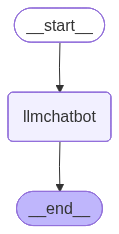

In [9]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
response = graph.invoke({'messages':'Hi, provide a recent ai news article.'})

In [11]:
response['messages'][-1].content

'**AI News Flash –\u202fDecember\u202f12\u202f2025**\n\n**Title:** *“OpenAI Unveils GPT‑5 with Real‑Time Multimodal Reasoning and Self‑Supervised Learning”*  \n**Source:** *The Verge* –\u202f[https://www.theverge.com/2025/12/12/openai-gpt5-announcement](https://www.theverge.com/2025/12/12/openai-gpt5-announcement)  \n**Published:**\u202fDecember\u202f12,\u202f2025  \n\n---\n\n### TL;DR  \nOpenAI announced **GPT‑5**, its next‑generation large‑language‑model platform. The new system can process and generate **text, images, audio, video, and code simultaneously**, and it learns continuously from user interactions using a **self‑supervised feedback loop**. Early demos show real‑time reasoning across modalities (e.g., answering a question about a live video feed while generating a code snippet). OpenAI says GPT‑5 will be rolled out to ChatGPT Plus subscribers in early 2026, with an enterprise‑grade API slated for Q1\u202f2026.\n\n---\n\n### Key Highlights\n\n| Aspect | What’s New in GPT‑5 |

### ChatBot wtih Tool


In [12]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke('recent AI news articles')

c:\Users\haris\Desktop\Agentic AI Workspace\AgenticLanggraph\.venv\Lib\site-packages\langchain_tavily\tavily_research.py:97: UserWarning: Field name "output_schema" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]
c:\Users\haris\Desktop\Agentic AI Workspace\AgenticLanggraph\.venv\Lib\site-packages\langchain_tavily\tavily_research.py:97: UserWarning: Field name "stream" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]


{'query': 'recent AI news articles',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.artificialintelligence-news.com/',
   'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
   'content': "Thailand becomes one of the first in Asia to get the Sora app · Malaysia launches Ryt Bank, its first AI-powered bank · Google's Veo 3 AI video creation tools are",
   'score': 0.7418428,
   'raw_content': None},
  {'url': 'https://aimagazine.com/',
   'title': 'AI Magazine: Home of AI and Artificial Intelligence News',
   'content': 'This week, Trump is impacting AI regulations, Perplexity gains a celebrity investor and GoogleCloud progresses energy goals for data centres to scale AI…',
   'score': 0.7355091,
   'raw_content': None}],
 'response_time': 0.79,
 'request_id': '949b3e76-6c86-4ddb-b0db-fa126e28ca83'}

In [13]:
## Custom Function
def multiply(a: int, b: int) -> int:
    """ _summay_

    Args:
        a (int): _first int_
        b (int): _second int_

    Returns: 
        int: output int
    """
    return a * b


In [14]:
tools = [tool, multiply]

In [15]:
llm_with_tools = llm.bind_tools(tools)

In [16]:
llm_with_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000019A02CD1E80>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000019A02CD2BA0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input shou

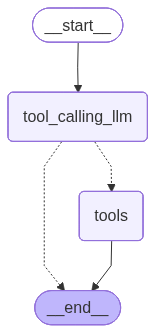

In [17]:
## State Graph with Tools
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition 

## Node Definition
def tool_calling_llm(state: State):
    return {'messages':[llm_with_tools.invoke(state['messages'])]}

## Graph
builder = StateGraph(State)
builder.add_node('tool_calling_llm', tool_calling_llm)
builder.add_node('tools', ToolNode(tools))

## Edges
builder.add_edge(START,'tool_calling_llm')
builder.add_conditional_edges('tool_calling_llm',tools_condition) 
builder.add_edge('tools',END)

## Compile the Graph
graph = builder.compile()
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
response = graph.invoke({'messages':'What is the recent AI news'})


In [19]:
response['messages'][-1].content

'{"query": "latest AI news week", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.newsweek.com/nw-ai/ai-impact-the-cost-of-playing-it-safe-11197101", "title": "AI Impact: The Cost of Playing It Safe - Newsweek", "score": 0.979354, "published_date": "Thu, 11 Dec 2025 19:10:35 GMT", "content": "Experience some AI magic? Tell us about it at ai.newsletter@newsweek.com\\n\\nTap or click here to get this newsletter delivered to your inbox.\\n\\nRequest Reprint & LicensingView Editorial & AI Guidelines\\n\\nAdd Newsweek as a preferred source on Google to see more of our trusted coverage when you search.\\n\\n## Recommended For You\\n\\nNewsweek.AI\\n\\nHow IBM Reinvented Itself With AI\\n\\n9 min read\\n\\nNewsweek.AI\\n\\n4 Quiet Ways AI Is Transforming the SaaS Industry\\n\\n8 min read\\n\\nAI [...] NewslettersFacebookInstagramYouTubeTikTokTwitter/XRedditAnnouncementsLeadershipDev Pragad\\n More\\n\\n  UnconventionalEventsPodcastsVantageReaders Ch

In [20]:
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

What is the recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_6ce24376-3186-45df-b962-b88921ed23bc)
 Call ID: fc_6ce24376-3186-45df-b962-b88921ed23bc
  Args:
    query: latest AI news week
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news week", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.newsweek.com/nw-ai/ai-impact-the-cost-of-playing-it-safe-11197101", "title": "AI Impact: The Cost of Playing It Safe - Newsweek", "score": 0.979354, "published_date": "Thu, 11 Dec 2025 19:10:35 GMT", "content": "Experience some AI magic? Tell us about it at ai.newsletter@newsweek.com\n\nTap or click here to get this newsletter delivered to your inbox.\n\nReq

In [21]:
response = graph.invoke({'messages':'What is 5 multiplied by 2? and also provide recent AI news articles.'})

In [22]:
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2? and also provide recent AI news articles.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_a7f9869d-e1a1-4039-ba46-311c48329c92)
 Call ID: fc_a7f9869d-e1a1-4039-ba46-311c48329c92
  Args:
    query: latest AI news
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.pcmag.com/news/big-techs-get-rich-quick-scheme-for-ai-fire-everyone-release-a-mediocre", "title": "Big Tech's Get-Rich-Quick Scheme for AI: Fire Everyone, Release a Mediocre Model - PCMag", "score": 0.94776917, "published_date": "Sat, 13 Dec 2025 12:00:31 GMT", "content": "OpenAI CEO Sam Altman makes his late-night TV debut on

### ReACT Agent Architecture


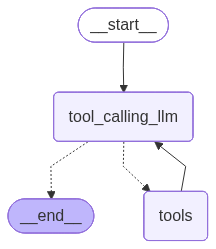

In [23]:
## State Graph with Tools
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition 

## Node Definition
def tool_calling_llm(state: State):
    return {'messages':[llm_with_tools.invoke(state['messages'])]}

## Graph
builder = StateGraph(State)
builder.add_node('tool_calling_llm', tool_calling_llm)
builder.add_node('tools', ToolNode(tools))

## Edges
builder.add_edge(START,'tool_calling_llm')
builder.add_conditional_edges('tool_calling_llm',tools_condition) 
builder.add_edge('tools', 'tool_calling_llm')

## Compile the Graph
graph = builder.compile()
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
response = graph.invoke({'messages':'Provide a recent AI news article and multiply 6 by 7.'})
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

Provide a recent AI news article and multiply 6 by 7.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_04cbf682-54df-4c6b-bd0c-7ecee0c10b8a)
 Call ID: fc_04cbf682-54df-4c6b-bd0c-7ecee0c10b8a
  Args:
    query: latest AI news October 2024
    search_depth: advanced
    time_range: month
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news October 2024", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.justice.gov/opa/pr/us-authorities-shut-down-major-china-linked-ai-tech-smuggling-network", "title": "U.S. Authorities Shut Down Major China-Linked AI Tech Smuggling ...", "content": "According to court documents, Alan Hao Hsu, also known as Haochun Hsu, 43, of Missouri City, Texas, and his company, Hao Global LLC, 

In [25]:
response = graph.invoke({'messages':'Hi, My name is Harish'})
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

Hi, My name is Harish
================================== Ai Message ==================================

Hello Harish! 👋 Nice to meet you. How can I assist you today?


In [26]:
response = graph.invoke({'messages':'What is my name?'})
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don’t have any information about your name. If you’d like me to address you a certain way, just let me know!


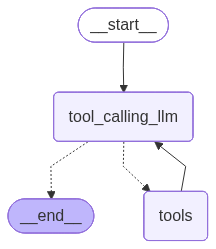

In [27]:
## State Graph with Tools
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node Definition
def tool_calling_llm(state: State):
    return {'messages':[llm_with_tools.invoke(state['messages'])]}

## Graph
builder = StateGraph(State)
builder.add_node('tool_calling_llm', tool_calling_llm)
builder.add_node('tools', ToolNode(tools))

## Edges
builder.add_edge(START,'tool_calling_llm')
builder.add_conditional_edges('tool_calling_llm',tools_condition) 
builder.add_edge('tools', 'tool_calling_llm')

## Compile the Graph
graph = builder.compile(checkpointer = memory)
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
config = {'configurable':{'thread_id':'1'}}

response = graph.invoke({'messages':'Hi, My name is Harish'}, config = config)

response

{'messages': [HumanMessage(content='Hi, My name is Harish', additional_kwargs={}, response_metadata={}, id='d9bbadb1-03d9-46ba-aeb2-8b1c3bcbb635'),
  AIMessage(content='Hello Harish! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user just says "Hi, My name is Harish". Likely they want a greeting. We should respond politely, perhaps ask how we can help.'}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 340, 'total_tokens': 398, 'completion_time': 0.127572506, 'completion_tokens_details': {'reasoning_tokens': 33}, 'prompt_time': 0.007583849, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.054782851, 'total_time': 0.135156355}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_70d048ba3c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019b25da-5b86-7363-af54-22adcdd6ccf9-0', usage_metadata={'input_tokens': 340, 'output_

In [29]:
response['messages'][-1].content

'Hello Harish! Nice to meet you. How can I assist you today?'

In [30]:
response = graph.invoke({'messages':'Hey, What is my name?'}, config = config)

response['messages'][-1].content

'Your name is Harish.'

### Streaming

In [31]:
from langgraph.checkpoint.memory import MemorySaver
memory_loader = MemorySaver()

In [32]:
def superbot(state: State):
    return {'messages':[llm.invoke(state['messages'])]}

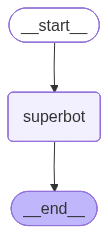

In [33]:
grpah = StateGraph(State)

# node
grpah.add_node('superbot', superbot)
# edge

grpah.add_edge(START,'superbot')
grpah.add_edge('superbot',END)

graph_builder = grpah.compile(checkpointer = memory) 

# Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [34]:
# Innvocation
config = {'configurable':{'thread_id':'1'}}

response = graph_builder.invoke({'messages':'Hello, Who am I, I like listening to music?'}, config = config)

In [35]:
response['messages'][-1].content

'You’re Harish, and you enjoy listening to music. 🎧 If there’s anything specific you’d like to chat about—new songs, favorite artists, or anything else—just let me know!'

In [36]:
config = {'configurable':{'thread_id':'3'}}

for chunck in graph_builder.stream({'messages':'Hi, my name is Harish and I like movies?'}, config, stream_mode = 'updates'):
    print(chunck)

{'superbot': {'messages': [AIMessage(content='Hey Harish! Great to meet you. 🎬  \nWhat kind of movies do you enjoy? Are you into action, sci‑fi, dramas, comedies, or something else? Any favorite films or directors you’d recommend? Let’s chat about movies!', additional_kwargs={'reasoning_content': 'The user says: "Hi, my name is Harish and I like movies?" They are greeting and stating name and interest. Probably respond friendly, ask about movies. No disallowed content. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 105, 'prompt_tokens': 83, 'total_tokens': 188, 'completion_time': 0.253944507, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.003344166, 'prompt_tokens_details': None, 'queue_time': 0.053647544, 'total_time': 0.257288673}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e88ce9c728', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019b25da-6cfb-7000

In [37]:
for chunck in graph_builder.stream({'messages':'Hi, my name is Harish and I like movies?'}, config, stream_mode = 'values'):
    print(chunck)

{'messages': [HumanMessage(content='Hi, my name is Harish and I like movies?', additional_kwargs={}, response_metadata={}, id='e0e5f2ce-9d7d-4a9e-83b2-e740ac999b39'), AIMessage(content='Hey Harish! Great to meet you. 🎬  \nWhat kind of movies do you enjoy? Are you into action, sci‑fi, dramas, comedies, or something else? Any favorite films or directors you’d recommend? Let’s chat about movies!', additional_kwargs={'reasoning_content': 'The user says: "Hi, my name is Harish and I like movies?" They are greeting and stating name and interest. Probably respond friendly, ask about movies. No disallowed content. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 105, 'prompt_tokens': 83, 'total_tokens': 188, 'completion_time': 0.253944507, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.003344166, 'prompt_tokens_details': None, 'queue_time': 0.053647544, 'total_time': 0.257288673}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e8

In [38]:
config = {'configurable':{'thread_id':'4'}}

for chunck in graph_builder.stream({'messages':'I also like video games?'}, config, stream_mode = 'values'):
    print(chunck)

{'messages': [HumanMessage(content='I also like video games?', additional_kwargs={}, response_metadata={}, id='caf6bd98-12e6-49fe-8438-198037db5857')]}
{'messages': [HumanMessage(content='I also like video games?', additional_kwargs={}, response_metadata={}, id='caf6bd98-12e6-49fe-8438-198037db5857'), AIMessage(content='That’s awesome—music and video games make a perfect pair! 🎮🎧  \n\nHere are a few ways you can blend your love of music with some great gaming experiences, plus some titles you might enjoy based on different tastes. Let me know which ones sound appealing, or tell me what platforms you have (PC, console, Switch, mobile, etc.) and the kinds of games you gravitate toward, and I can fine‑tune the list.\n\n---\n\n## 1️⃣ Games with Legendary Soundtracks\n\n| Game | Genre / Core Loop | Why the music shines | Platform(s) |\n|------|-------------------|----------------------|-------------|\n| **Hades** | Roguelike action | Composer Darren Korb mixes rock, funk, and Greek‑mythic m

### Human in the loop

In [57]:
import os 
from langchain.chat_models import init_chat_model
llm = init_chat_model('groq:openai/gpt-oss-120b')
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000019A067CEC40>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000019A067CF5C0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [62]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({'query': query})
    return human_response['data']

tool = TavilySearch(max_results=2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools.invoke(state['messages'])
    return {'messages':[message]}

graph_builder.add_node('chatbot', chatbot)

tool_node = ToolNode(tools = tools)
graph_builder.add_node('tools', tool_node)

graph_builder.add_conditional_edges('chatbot', tools_condition)
graph_builder.add_edge('tools', 'chatbot')
graph_builder.add_edge(START,'chatbot')



In [63]:
memory = MemorySaver()

graph = graph_builder.compile(checkpointer = memory)


In [64]:
from IPython.display import Image, display

try:
    display(Image(graph_builder.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [ ]:
user_input = "I need some expert guidance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events =graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)
# Assuming 'events' is the result of graph.stream(...)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()
        

================================ Human Message =================================

I need some expert guidance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_92c513c0-1f6d-4209-bf91-258d2545631c)
 Call ID: fc_92c513c0-1f6d-4209-bf91-258d2545631c
  Args:
    query: User needs expert guidance for building an AI agent and wants to request assistance from a human.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_92c513c0-1f6d-4209-bf91-258d2545631c)
 Call ID: fc_92c513c0-1f6d-4209-bf91-258d2545631c
  Args:
    query: User needs expert guidance for building an AI agent and wants to request assistance from a human.


In [66]:
human_response = (
    'We, the experts are here to help! We recommed you check out Langgraph to build your agent.'
    'It is much more relaible and efficient.')

humman_command = Command(resume = {'data':human_response})

events = graph.stream(humman_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_92c513c0-1f6d-4209-bf91-258d2545631c)
 Call ID: fc_92c513c0-1f6d-4209-bf91-258d2545631c
  Args:
    query: User needs expert guidance for building an AI agent and wants to request assistance from a human.
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We recommed you check out Langgraph to build your agent.It is much more relaible and efficient.
================================== Ai Message ==================================

Sure! I’ve reached out for you, and the experts got back right away:

> **“We, the experts, are here to help! We recommend you check out **[LangGraph](https://langchain.com/langgraph)** to build your agent. It’s much more reliable and efficient.”**

---

### Quick Overview of LangGraph
- **Purpose‑built for multi‑step, stateful workflows** (think planning, too